# Projekat: Analiza Sentimenta Steam Recenzija
## Tema: Primena Vestackih Neuronskih Mreza

**Dataset:** [Steam Reviews](https://www.kaggle.com/datasets/luthfim/steam-reviews-dataset)

**Cilj:** Predvidjanje sentimenta recenzije (pozitivno/negativno) na osnovu teksta.

**Biblioteke**: TensorFlow/Keras, scikit-learn, pandas, numpy

## Ucitavanje biblioteka i podataka

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [73]:
df = pd.read_csv('data/steam_reviews.csv')

df.head()

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2019-02-10,2,4,578,False,Recommended,&gt Played as German Reich&gt Declare war on B...,Expansion - Hearts of Iron IV: Man the Guns
1,2019-02-10,0,0,184,False,Recommended,yes.,Expansion - Hearts of Iron IV: Man the Guns
2,2019-02-07,0,0,892,False,Recommended,Very good game although a bit overpriced in my...,Expansion - Hearts of Iron IV: Man the Guns
3,2018-06-14,126,1086,676,False,Recommended,Out of all the reviews I wrote This one is pro...,Dead by Daylight
4,2017-06-20,85,2139,612,False,Recommended,Disclaimer I survivor main. I play games for f...,Dead by Daylight


## Deskriptivna analiza

### Istrazivanje dataseta

In [74]:
print(f"Shape: {df.shape}")
print("\nNaziv kolona:")
print(df.columns.tolist())

print('\nInformacije o datasetu:')
print(df.info())
print('\nDistribucija sentimenta')
print(df['recommendation'].value_counts())
print('Statistike')
print(df.describe())

Shape: (434891, 8)

Naziv kolona:
['date_posted', 'funny', 'helpful', 'hour_played', 'is_early_access_review', 'recommendation', 'review', 'title']

Informacije o datasetu:
<class 'pandas.DataFrame'>
RangeIndex: 434891 entries, 0 to 434890
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   date_posted             434891 non-null  str  
 1   funny                   434891 non-null  int64
 2   helpful                 434891 non-null  int64
 3   hour_played             434891 non-null  int64
 4   is_early_access_review  434891 non-null  bool 
 5   recommendation          434891 non-null  str  
 6   review                  433375 non-null  str  
 7   title                   434891 non-null  str  
dtypes: bool(1), int64(3), str(4)
memory usage: 23.6 MB
None

Distribucija sentimenta
recommendation
Recommended        303593
Not Recommended    131298
Name: count, dtype: int64
Statistike
              funn

In [75]:
print('\nBroj nedostajucih vrednosti:\n')
print(df.isnull().sum())


Broj nedostajucih vrednosti:

date_posted                  0
funny                        0
helpful                      0
hour_played                  0
is_early_access_review       0
recommendation               0
review                    1516
title                        0
dtype: int64


### Data cleanup

In [76]:
df = df.copy()

In [77]:
missing_values = df['review'].isnull().sum()
print(f'Broj redova pre ciscenja: {len(df)}')
print(f"Nedostajuce vrednosti u 'review': {missing_values}")

df = df.dropna(subset=['review'])

df = df.reset_index(drop=True)

null_count = df['review'].isnull().sum()
print(f'\nBroj redova posle ciscenja: {len(df)}')
print(f'Nedostajuce vrednosti nakon ciscenja: {null_count}')
print(f'Uklonjeno redova: {missing_values}')

Broj redova pre ciscenja: 434891
Nedostajuce vrednosti u 'review': 1516

Broj redova posle ciscenja: 433375
Nedostajuce vrednosti nakon ciscenja: 0
Uklonjeno redova: 1516


### Distribucija Sentimenta

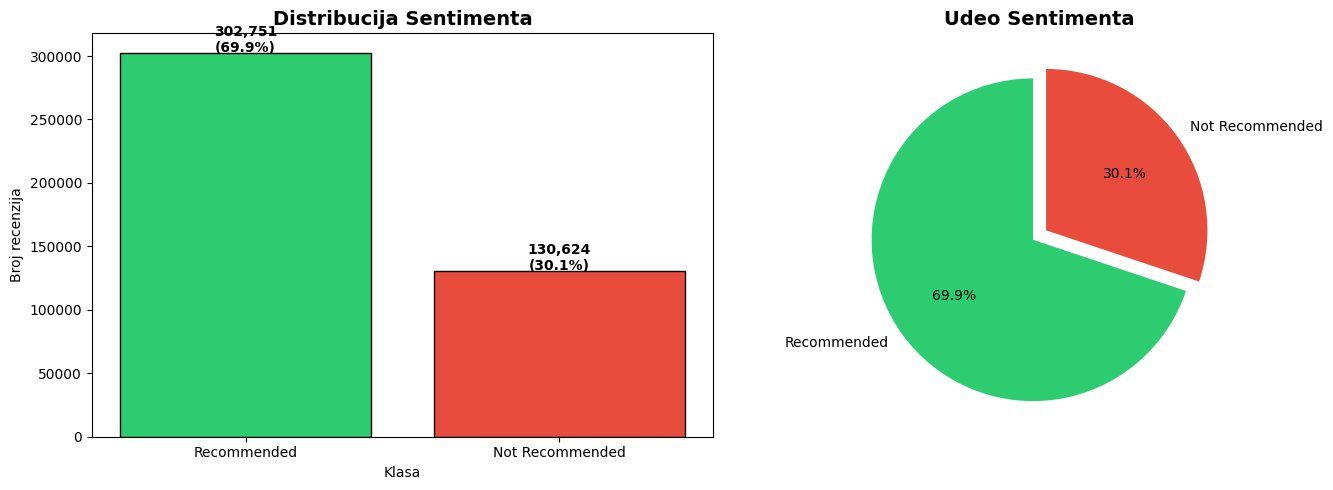

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df['recommendation'].value_counts()

axes[0].bar(sentiment_counts.index, sentiment_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribucija Sentimenta', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Broj recenzija')

for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontweight='bold')

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Udeo Sentimenta', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Statistike duzine recenzija
                    count   mean     std  min  25%   50%   75%     max
recommendation                                                        
Not Recommended  130624.0  54.63  101.96  1.0  7.0  22.0  59.0  2895.0
Recommended      302751.0  34.46   78.94  1.0  4.0  11.0  32.0  7984.0


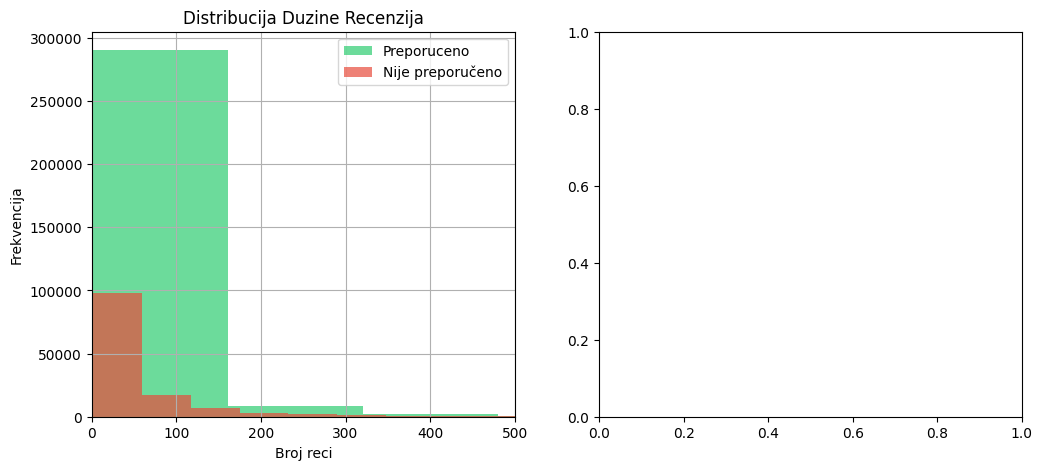

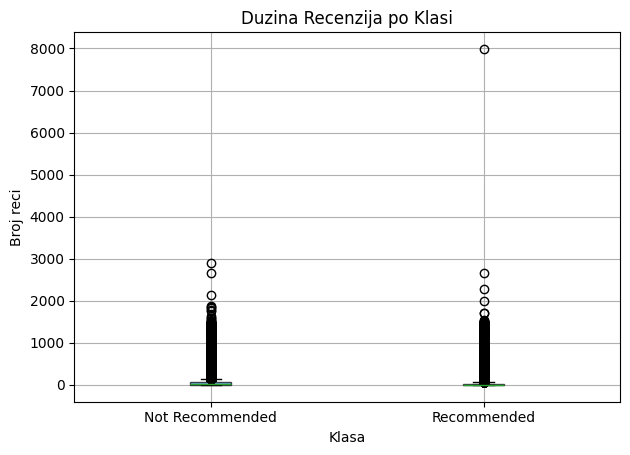

In [79]:
df['duzina_recenzije'] = df['review'].astype(str).apply(lambda x: len(x.split()))

print("Statistike duzine recenzija")
print(df.groupby('recommendation')['duzina_recenzije'].describe().round(2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df[df['recommendation'] == 'Recommended']['duzina_recenzije'].hist(
    bins=50, color='#2ecc71', alpha=0.7, label='Preporuceno')
df[df['recommendation'] == 'Not Recommended']['duzina_recenzije'].hist(
    bins=50, color='#e74c3c', alpha=0.7, label='Nije preporučeno')
plt.xlim(0, 500)
plt.title('Distribucija Duzine Recenzija')
plt.xlabel('Broj reci')
plt.ylabel('Frekvencija')
plt.legend()

plt.subplot(1, 2, 2)
df.boxplot(column='duzina_recenzije', by='recommendation', 
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7))
plt.title('Duzina Recenzija po Klasi')
plt.suptitle('')
plt.xlabel('Klasa')
plt.ylabel('Broj reci')

plt.tight_layout()
plt.show()

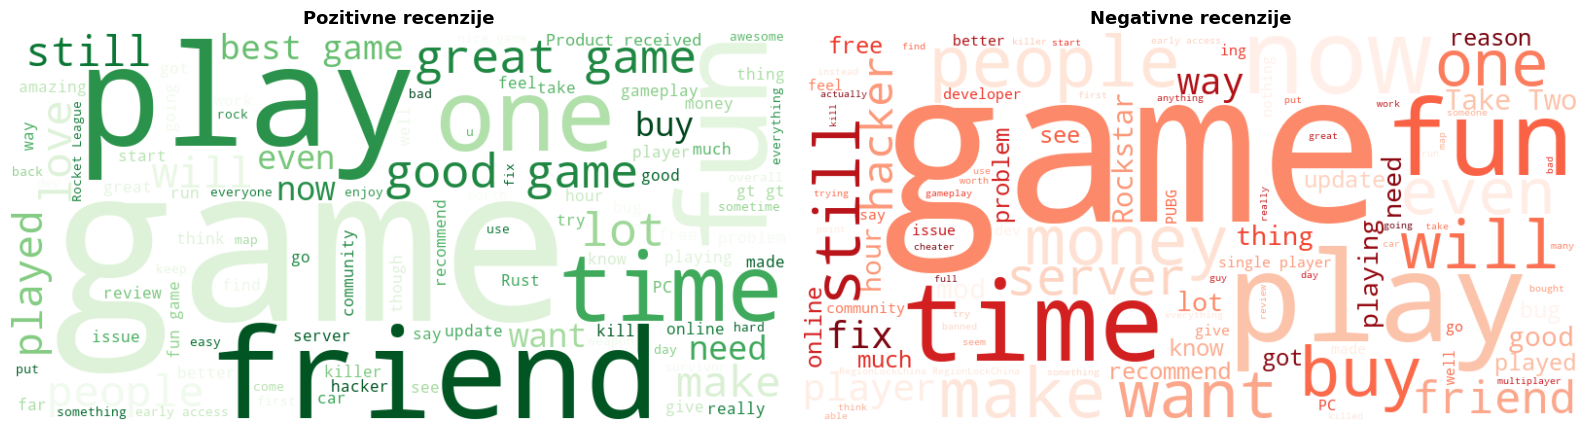

In [80]:
positive_text = ' '.join(
    df[df['recommendation'] == 'Recommended']['review'].astype(str).tolist()
)

negative_text = ' '.join(
    df[df['recommendation'] == 'Not Recommended']['review'].astype(str).tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Pozitivne recenzije', fontsize=13, fontweight='bold')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negativne recenzije', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Priprema teksta

### Ciscenje podataka

In [81]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['review'].apply(clean_text)

print("Primer ciscenja teksta\n")
for i in range(3):
    print(f"[{i+1}] Original:\n{df['review'].iloc[i]}")
    print(f"    Ociscen:\n{df['review_clean'].iloc[i]}")
    print()

Primer ciscenja teksta

[1] Original:
&gt Played as German Reich&gt Declare war on Belgium&gt Can't break Belgium so go through France&gt Capitulate France in order to get to Belgium&gt Get True Blitzkrieg achievementThis game is dad
    Ociscen:
gt played as german reichgt declare war on belgiumgt cant break belgium so go through francegt capitulate france in order to get to belgiumgt get true blitzkrieg achievementthis game is dad

[2] Original:
yes.
    Ociscen:
yes

[3] Original:
Very good game although a bit overpriced in my opinion. I'd prefer playing the game with mods (historical accuracy so on) although the vanilla version is good aswell. 7/10
    Ociscen:
very good game although a bit overpriced in my opinion id prefer playing the game with mods historical accuracy so on although the vanilla version is good aswell



### Enkodiranje klasa

In [82]:
df['label'] = (df['recommendation'] == 'Recommended').astype(int)

print("'Recommended': 1")
print("'Not Recommended': 0")
print()
print(df['label'].value_counts())

'Recommended': 1
'Not Recommended': 0

label
1    302751
0    130624
Name: count, dtype: int64


### Train/Test split

In [83]:
X = df['review_clean'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

print(f'Ukupno recenzija: {len(df):,}')
print(f'Train: {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test: {len(X_test):,} ({len(X_test)/len(df)*100:.0f}%)')

Ukupno recenzija: 433,375
Train: 346,700 (80%)
Test: 86,675 (20%)


### Balansiranje klasa (Class Weights)

In [90]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print(f"0 - Not Recommended: {class_weight_dict[0]:.4f}")
print(f"1 - Recommended:    {class_weight_dict[1]:.4f}")
print()
print(f"Greska na negativnoj recenziji kosta {class_weight_dict[0]:.2f}x vise")
print(f"Greska na pozitivnoj recenziji kosta {class_weight_dict[1]:.2f}x vise")

0 - Not Recommended: 1.6589
1 - Recommended:    0.7157

Greska na negativnoj recenziji kosta 1.66x vise
Greska na pozitivnoj recenziji kosta 0.72x vise


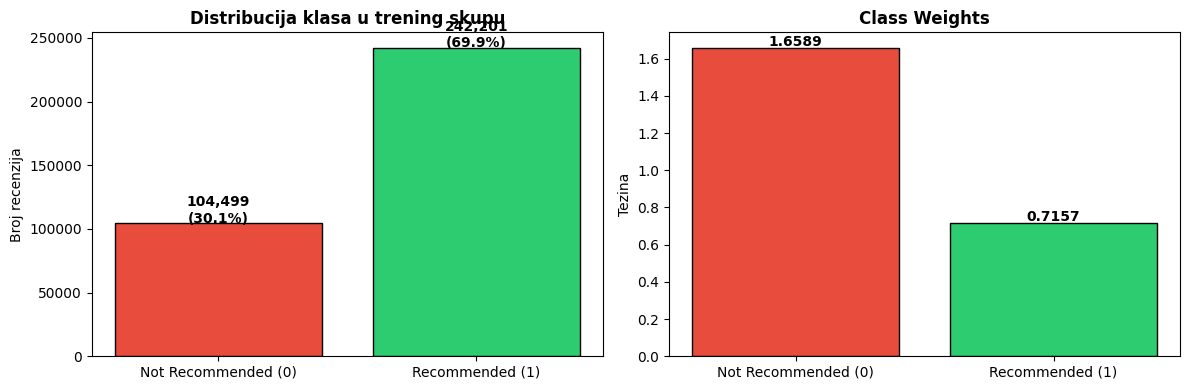

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

klase = ['Not Recommended (0)', 'Recommended (1)']
counts = [sum(y_train == 0), sum(y_train == 1)]
axes[0].bar(klase, counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribucija klasa u trening skupu', fontweight='bold')
axes[0].set_ylabel('Broj recenzija')
for i, v in enumerate(counts):
    axes[0].text(i, v + 500, f'{v:,}\n({v/sum(counts)*100:.1f}%)',
                ha='center', fontweight='bold')

weights = [class_weight_dict[0], class_weight_dict[1]]
axes[1].bar(klase, weights, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Class Weights', fontweight='bold')
axes[1].set_ylabel('Tezina')
for i, v in enumerate(weights):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Tokenizacija

In [84]:
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Velicina recnika:    {len(tokenizer.word_index):,} jedinstvenih reci")
print(f"Koristimo top:       {MAX_WORDS:,} reci")
print(f"Max duzina:          {MAX_LEN} reci po recenziji")
print(f"Shape X_train_pad:   {X_train_pad.shape}")
print(f"Shape X_test_pad:    {X_test_pad.shape}")
print()
print(f"Primer recenzije:    '{X_train[0][:80]}...'")
print(f"Nakon tokenizacije:  {X_train_seq[0][:10]}...")
print(f"Nakon paddinga:      {X_train_pad[0][:10]}...")

Velicina recnika:    236,959 jedinstvenih reci
Koristimo top:       20,000 reci
Max duzina:          200 reci po recenziji
Shape X_train_pad:   (346700, 200)
Shape X_test_pad:    (86675, 200)

Primer recenzije:    'look at my hours in game and let that soak in for a second in the beggining pubg...'
Nakon tokenizacije:  [291, 39, 29, 78, 14, 3, 4, 334, 16, 13496]...
Nakon paddinga:      [  291    39    29    78    14     3     4   334    16 13496]...
